# U-TAE on PASTIS — AgroSatCopilot Baseline

**Model:** U-TAE (U-Net + Lightweight Temporal Attention Encoder)  
**Dataset:** PASTIS-R (semantic segmentation)  
**Target runtime:** ~2–3 h on Colab L4  
**Temporal depth:** T = 10 timesteps  
**Patch size:** 128 × 128 px  
**Batch size:** 4  

Reference: *Garnot & Landrieu, ICCV 2021 — Panoptic Segmentation of Satellite Image Time Series with Convolutional Temporal Attention Networks*

## Workflow
1. Mount Google Drive & detect Colab
2. Install dependencies
3. UTAE & LTAE2d model definition (self-contained, no external repo needed)
4. Hyperparameters, class map & HCAT grouping
5. Dataset & DataLoaders (multi-temporal, T=10)
6. Optimizer, scheduler & metrics (mIoU + F1-macro)
7. Training loop
8. Training curves
9. Evaluate on test set
10. HCAT Level-1 grouped evaluation
11. Qualitative predictions
12. Save model & copy outputs to Drive

## 0. Runtime check

In [15]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError('No GPU found! Go to Runtime → Change runtime type → GPU (L4 recommended).')
print(result.stdout)

Tue Jun  2 04:42:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   70C    P0             36W /   72W |    2418MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Mount Drive & detect environment

In [16]:
import os, sys, subprocess
from pathlib import Path
import shutil

_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# En Colab el repo no esta presente: se clona una vez en /content/agrosat-copilot.
if _IN_COLAB:
    from getpass import getpass
    _repo_dir = '/content/agrosat-copilot'
    _branch = 'main'
    _repo = 'github.com/ArthurZizumbo/agrosat-copilot.git'
    if not Path(_repo_dir, 'pyproject.toml').is_file():
        _rc = os.system(f'git clone --branch {_branch} --depth 1 https://{_repo} {_repo_dir}')
        if _rc != 0:
            _tok = getpass('GitHub token (repo privado): ')
            os.system(f'git clone --branch {_branch} --depth 1 https://{_tok}@{_repo} {_repo_dir}')

# Localizar el repo por su pyproject.toml
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break
else:
    raise RuntimeError('No se encontro el repo agrosat-copilot (pyproject.toml).')

if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'einops',
                    'geopandas', 'pyarrow', 'rasterio', 'torchmetrics',
                    'mlflow', 'tqdm', 'matplotlib', 'polars'], check=False)

print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
repo: /content/agrosat-copilot | colab: True | drive: /content/drive/MyDrive/Integrador/


In [17]:
import torch

MODEL = 'utae'

PASTIS_ROOT = Path((shared_folder_path + 'data/PASTIS-R') if shared_folder_path
               else 'data/PASTIS-R')
SEG_DIR       = Path((shared_folder_path if shared_folder_path else '') + 'reports/segmentation')
METRICS_DIR   = SEG_DIR / 'metrics'
FIGURES_DIR   = SEG_DIR / 'figures'
CHECKPOINT_DIR = SEG_DIR / 'checkpoints'
for _d in (METRICS_DIR, FIGURES_DIR, CHECKPOINT_DIR):
    _d.mkdir(parents=True, exist_ok=True)
COMPARISON_PATH = METRICS_DIR / f'model_comparison_avance4_{MODEL}.parquet'

# Directorio local temporal
OUTPUT_DIR = '/content/outputs/utae_pastis'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DRIVE_OUTPUT_DIR = str(CHECKPOINT_DIR)

FEATURES_PATH      = shared_folder_path + 'data/test_fixtures/feature_selection_parcels_subset.parquet'
PARCELS_GEOPARQUET = shared_folder_path + 'data/processed/pastis_parcels_full.geoparquet'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('modelo:', MODEL, '| device:', DEVICE)
print('PASTIS_ROOT:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
print('artefactos en:', SEG_DIR)


modelo: utae | device: cuda
PASTIS_ROOT: /content/drive/MyDrive/Integrador/data/PASTIS-R | exists: True
artefactos en: /content/drive/MyDrive/Integrador/reports/segmentation


## 2. Install dependencies

In [18]:
import json, random, math, time, warnings
from datetime import datetime
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchmetrics import JaccardIndex, F1Score

from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cuda
GPU : NVIDIA L4
VRAM: 23.7 GB


## 3. U-TAE model definition (self-contained)

Faithful port of Garnot & Landrieu (ICCV 2021). No external repo clone needed.

In [19]:
# ── LTAE2d — Lightweight Temporal Attention Encoder (spatial variant) ─────────

class LTAE2d(nn.Module):
    """
    Lightweight Temporal Attention Encoder applied at every spatial position.
    Input : (B, T, C, H, W)
    Output: (B, C_out, H, W)  — temporally aggregated feature map
    """
    def __init__(
        self,
        in_channels=128,
        n_head=16,
        d_k=4,
        mlp_in=[256, 128],
        dropout=0.2,
        d_model=256,
        T=1000,
        return_att=False,
        positional_encoding=True,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.n_head = n_head
        self.return_att = return_att
        self.d_k = d_k

        if positional_encoding:
            self.positional_encoder = PositionalEncoding(
                d=in_channels, T=T, repeat=None
            )
        else:
            self.positional_encoder = None

        # Master query
        self.inlayernorm  = nn.LayerNorm(in_channels)
        self.outlayernorm = nn.LayerNorm(mlp_in[-1])

        # Key network (maps in_channels → n_head * d_k per timestep)
        self.key_net = nn.Sequential(*[
            nn.Linear(in_channels // n_head, d_k)
        ])

        # MLP for the global query
        self.query = nn.Sequential(
            nn.Linear(in_channels, in_channels),
            nn.ReLU(),
        )

        # MLP applied after attention
        layers = []
        for i in range(len(mlp_in) - 1):
            layers.extend([
                nn.Linear(mlp_in[i], mlp_in[i + 1]),
                nn.BatchNorm1d(mlp_in[i + 1]),
                nn.ReLU(),
            ])
        self.mlp = nn.Sequential(*layers)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, batch_positions=None, return_att=False):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        if self.positional_encoder is not None and batch_positions is not None:
            x = self.positional_encoder(x, batch_positions)  # (B, T, C, H, W)

        # Reshape for attention: treat spatial positions as batch
        # (B*H*W, T, C)
        x_flat = x.permute(0, 3, 4, 1, 2).contiguous().view(B * H * W, T, C)
        x_flat = self.inlayernorm(x_flat)

        # Global query: average over time then project
        # (B*H*W, C)
        q = self.query(x_flat.mean(dim=1))

        # Split into heads: (B*H*W, T, n_head, C//n_head)
        x_heads = x_flat.view(B * H * W, T, self.n_head, C // self.n_head)
        q_heads = q.view(B * H * W, self.n_head, C // self.n_head)

        # Keys: (B*H*W, T, n_head, d_k)
        k = self.key_net(x_heads)  # (B*H*W, T, n_head, d_k)

        # Queries: (B*H*W, n_head, d_k)
        q_k = self.key_net(q_heads)  # (B*H*W, n_head, d_k)

        # Attention scores: (B*H*W, n_head, T)
        att = torch.einsum('bnd,btnd->bnt', q_k, k) / math.sqrt(self.d_k)
        att = F.softmax(att, dim=-1)  # (B*H*W, n_head, T)
        att = self.dropout(att)

        # Weighted sum over time: (B*H*W, n_head, C//n_head)
        out = torch.einsum('bnt,btnc->bnc', att, x_heads)  # (B*H*W, n_head, C//n_head)
        out = out.view(B * H * W, C)   # (B*H*W, C)

        # MLP
        out = self.outlayernorm(self.mlp(out))  # (B*H*W, C_out)
        out = out.view(B, H, W, -1).permute(0, 3, 1, 2)  # (B, C_out, H, W)

        if self.return_att or return_att:
            # reshape att: (B, n_head, T, H, W)
            att_out = att.view(B, H, W, self.n_head, T).permute(0, 3, 4, 1, 2)
            return out, att_out
        return out


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding added to (B, T, C, H, W) time-series."""
    def __init__(self, d, T=1000, repeat=None):
        super().__init__()
        self.d = d
        self.T = T
        self.repeat = repeat

    def forward(self, x, positions):
        # x:         (B, T, C, H, W)
        # positions: (B, T)  — day-of-year integers
        B, T, C, H, W = x.shape
        pe = self._get_pe(positions, C, x.device)  # (B, T, C)
        pe = pe.unsqueeze(-1).unsqueeze(-1)         # (B, T, C, 1, 1)
        return x + pe

    def _get_pe(self, positions, d, device):
        # positions: (B, T)
        B, T = positions.shape
        div = torch.exp(
            torch.arange(0, d, 2, dtype=torch.float32, device=device)
            * (-math.log(self.T) / d)
        )  # (d//2,)
        pos = positions.float().unsqueeze(-1)  # (B, T, 1)
        pe  = torch.zeros(B, T, d, device=device)
        pe[:, :, 0::2] = torch.sin(pos * div)
        pe[:, :, 1::2] = torch.cos(pos * div)
        return pe


print('LTAE2d defined.')

LTAE2d defined.


In [20]:
# ── U-TAE building blocks ─────────────────────────────────────────────────────

class ConvLayer(nn.Module):
    """Conv → GroupNorm → ReLU."""
    def __init__(self, in_ch, out_ch, k=3, p=1, norm='group', n_groups=4):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=norm is None)]
        if norm == 'group':
            layers.append(nn.GroupNorm(n_groups, out_ch))
        elif norm == 'batch':
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.ReLU(inplace=True))
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv(x)


class DownConv(nn.Module):
    """Strided conv for downsampling."""
    def __init__(self, in_ch, out_ch, k=4, s=2, p=1, norm='group'):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.GroupNorm(4, out_ch) if norm == 'group' else nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UpConv(nn.Module):
    """Strided transposed conv for upsampling."""
    def __init__(self, in_ch, out_ch, k=4, s=2, p=1, norm='group'):
        super().__init__()
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.GroupNorm(4, out_ch) if norm == 'group' else nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


# ── Full U-TAE ────────────────────────────────────────────────────────────────

class UTAE(nn.Module):
    """
    U-Net with a Lightweight Temporal Attention Encoder (L-TAE) at the bottleneck
    and attention-weighted skip connections.

    Input : (B, T, C_in, H, W)  — multi-temporal S2 patch
    Output: (B, num_classes, H, W)
    """
    def __init__(
        self,
        input_dim=10,
        encoder_widths=(32, 32, 64, 128),
        decoder_widths=(32, 32, 64, 128),
        out_conv=(32, 20),
        n_head=16,
        d_model=256,
        d_k=4,
        encoder_norm='group',
        agg_mode='att_group',
        pad_value=0.0,
    ):
        super().__init__()
        self.encoder_widths = list(encoder_widths)
        self.decoder_widths = list(decoder_widths)
        self.pad_value = pad_value
        self.agg_mode  = agg_mode
        n_levels = len(encoder_widths)

        # ── Encoder stem: project input_dim → encoder_widths[0] for each timestep
        self.in_conv = ConvLayer(input_dim, encoder_widths[0], norm=encoder_norm)

        # ── Encoder downsampling blocks
        self.down_convs = nn.ModuleList([
            DownConv(encoder_widths[i], encoder_widths[i + 1], norm=encoder_norm)
            for i in range(n_levels - 1)
        ])

        # ── LTAE at bottleneck (deepest level)
        ltae_in = encoder_widths[-1]
        self.temporal_encoder = LTAE2d(
            in_channels=ltae_in,
            n_head=n_head,
            d_k=d_k,
            mlp_in=[ltae_in, ltae_in],
            d_model=d_model,
            return_att=True,
        )

        # ── Skip connection aggregators (one per skip level)
        # Each uses attention weights resampled from the bottleneck
        self.skip_agg = nn.ModuleList([
            ConvLayer(encoder_widths[i], encoder_widths[i], norm=encoder_norm)
            for i in range(n_levels - 1)
        ])

        # ── Decoder upsampling blocks
        self.up_convs = nn.ModuleList()
        self.dec_convs = nn.ModuleList()
        for i in range(n_levels - 1, 0, -1):
            in_ch  = decoder_widths[i]
            skip_ch = encoder_widths[i - 1]
            out_ch  = decoder_widths[i - 1]
            self.up_convs.append(UpConv(in_ch, out_ch, norm=encoder_norm))
            self.dec_convs.append(ConvLayer(out_ch + skip_ch, out_ch, norm=encoder_norm))

        # ── Output head
        head_layers = []
        in_ch = decoder_widths[0]
        for out_ch in out_conv:
            head_layers.append(nn.Conv2d(in_ch, out_ch, 1))
            if out_ch != out_conv[-1]:
                head_layers.append(nn.ReLU(inplace=True))
            in_ch = out_ch
        self.out_conv = nn.Sequential(*head_layers)

    # ------------------------------------------------------------------
    def forward(self, x, batch_positions=None):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        # ── Encode every timestep independently through the U-Net encoder
        # Result is a list of skip-maps per level, shape per level: (B, T, W_i, H_i, W_i)
        skips = []  # one entry per encoder level except bottleneck

        # Reshape to (B*T, C, H, W) for batch-wise convolutions
        xt = x.view(B * T, C, H, W)
        xt = self.in_conv(xt)  # (B*T, W0, H, W)

        # Save skip at level 0
        _, w0, h0, w0s = xt.shape
        skips.append(xt.view(B, T, w0, h0, w0s))

        for down in self.down_convs:
            xt = down(xt)
            _, wi, hi, wis = xt.shape
            skips.append(xt.view(B, T, wi, hi, wis))

        # skips[-1] is bottleneck: (B, T, W_n, H_n, W_n)
        # ── Temporal attention at bottleneck
        bottleneck = skips[-1]   # (B, T, W_n, Hn, Wn)
        # LTAE expects (B, T, C, H, W)
        feat, att = self.temporal_encoder(bottleneck, batch_positions)  # feat: (B, W_n, Hn, Wn)
        # att: (B, n_head, T, Hn, Wn) — used to aggregate skips

        # ── Aggregate skip connections using attention weights
        agg_skips = []
        for i, skip in enumerate(skips[:-1]):
            # skip: (B, T, Wi, Hi, Wi)
            _, _, Wi, Hi, Wis = skip.shape
            # Resample attention to this resolution: (B, n_head, T, Hi, Wis)
            att_up = F.interpolate(
                att.reshape(B * att.shape[1], T, att.shape[3], att.shape[4]),
                size=(Hi, Wis), mode='bilinear', align_corners=False
            ).reshape(B, att.shape[1], T, Hi, Wis)
            # Average attention over heads: (B, T, Hi, Wis)
            att_mean = att_up.mean(dim=1)  # (B, T, Hi, Wis)
            att_mean = F.softmax(att_mean, dim=1).unsqueeze(2)  # (B, T, 1, Hi, Wis)
            # Weighted sum: (B, Wi, Hi, Wis)
            agg = (skip * att_mean).sum(dim=1)  # (B, Wi, Hi, Wis)
            agg = self.skip_agg[i](agg)
            agg_skips.append(agg)

        # ── Decoder
        d = feat  # (B, W_n, Hn, Wn)
        for up, dec, skip in zip(self.up_convs, self.dec_convs, reversed(agg_skips)):
            d = up(d)                       # upsample
            d = torch.cat([d, skip], dim=1) # concatenate skip
            d = dec(d)

        return self.out_conv(d)  # (B, num_classes, H, W)


print('UTAE defined.')

UTAE defined.


## 4. Hyperparameters, class map & HCAT grouping

In [21]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
T_STEPS     = 10           # number of timesteps sampled per patch
IMG_SIZE    = 128          # spatial patch resolution
BATCH_SIZE  = 4
NUM_EPOCHS  = 40           # ~2–3 h on L4
LR          = 1e-3
WEIGHT_DECAY= 1e-4
NUM_WORKERS = 1
PIN_MEMORY  = True
NUM_BANDS   = 10           # all 10 Sentinel-2 bands (U-TAE needs the full time series)

# ── PASTIS-R class map (20 classes including Background & Void) ───────────────
PASTIS_CLASSES = [
    'Background',
    'Meadow', 'Soft winter wheat', 'Corn', 'Winter barley',
    'Winter rapeseed', 'Spring barley', 'Sunflower', 'Grapevine',
    'Beet', 'Winter triticale', 'Winter durum wheat', 'Fruits, vegetables, flowers',
    'Potatoes', 'Leguminous fodder', 'Soybeans', 'Orchard',
    'Mixed cereal', 'Sorghum', 'Void label',
]
NUM_CLASSES  = len(PASTIS_CLASSES)   # 20
IGNORE_INDEX = 19                    # Void label

id2label = {i: c for i, c in enumerate(PASTIS_CLASSES)}
label2id = {c: i for i, c in enumerate(PASTIS_CLASSES)}

# ── HCAT Level-1 grouping ─────────────────────────────────────────────────────
HCAT_L1_MAP = {
    0:  None,               # Background
    1:  'OTHER',            # Meadow
    2:  'CEREALS',          # Soft winter wheat
    3:  'CEREALS',          # Corn
    4:  'CEREALS',          # Winter barley
    5:  'OILSEEDS',         # Winter rapeseed
    6:  'CEREALS',          # Spring barley
    7:  'OILSEEDS',         # Sunflower
    8:  'PERMANENT_WOODY',  # Grapevine
    9:  'ROOT_CROPS',       # Beet
    10: 'CEREALS',          # Winter triticale
    11: 'CEREALS',          # Winter durum wheat
    12: 'OTHER',            # Fruits, vegetables, flowers
    13: 'LEGUMES',          # Leguminous fodder
    14: 'OILSEEDS',
    15: 'LEGUMES',          # Soybeans
    16: 'PERMANENT_WOODY',  # Orchard
    17: 'CEREALS',          # Mixed cereal
    18: 'CEREALS',          # Sorghum
    19: None,               # Void label
}
HCAT_GROUPS   = ['CEREALS', 'LEGUMES', 'OILSEEDS', 'OTHER', 'PERMANENT_WOODY', 'ROOT_CROPS']
HCAT_THRESHOLD = 0.40

print(f'Classes: {NUM_CLASSES} | ignore_index={IGNORE_INDEX}')
print(f'T={T_STEPS} | Patch={IMG_SIZE}px | Batch={BATCH_SIZE} | Epochs={NUM_EPOCHS}')

Classes: 20 | ignore_index=19
T=10 | Patch=128px | Batch=4 | Epochs=40


## 5. Dataset & DataLoaders (multi-temporal, T=10)

In [22]:
import torchvision.transforms.functional as TF


class PASTISMultiTempDataset(Dataset):
    """
    Multi-temporal PASTIS-R dataset for U-TAE.

    Returns T evenly-spaced timesteps from each patch's S2 time series.
    Image shape : (T, C, H, W)  float32
    Mask  shape : (H, W)        int64
    Positions   : (T,)          int64  day-of-year (0-364)
    """

    # Sentinel-2 per-band normalisation (PASTIS scale ~0-10000)
    S2_MEAN = [1158.0, 1244.7, 1416.3, 1374.8, 1619.0,
                2075.1, 2263.1, 2311.0, 2108.6,  817.4]
    S2_STD  = [ 671.7,  698.1,  761.3,  830.8,  795.3,
                907.5,  981.1,  993.7,  882.0,  504.2]

    def __init__(
        self,
        pastis_root: Path,
        fold_ids: list,
        img_size: int = 128,
        num_bands: int = 10,
        t_steps: int = 10,
        augment: bool = False,
    ):
        super().__init__()
        self.root     = Path(pastis_root)
        self.img_size = img_size
        self.num_bands = num_bands
        self.t_steps  = t_steps
        self.augment  = augment

        meta_path = self.root / 'metadata.geojson'
        if not meta_path.exists():
            raise FileNotFoundError(f'metadata.geojson not found in {self.root}')
        with open(meta_path) as f:
            meta = json.load(f)

        self.patch_ids = [
            feat['properties']['ID_PATCH']
            for feat in meta['features']
            if feat['properties']['Fold'] in fold_ids
        ]
        print(f'Fold {fold_ids} → {len(self.patch_ids)} patches')

    def __len__(self):
        return len(self.patch_ids)

    def _load_image(self, pid):
        """Load (T_full, C, H, W), sample T_steps, normalise → (T, C, H, W)."""
        s2 = np.load(self.root / 'DATA_S2' / f'S2_{pid}.npy')  # (T_full, C, H, W)
        T_full = s2.shape[0]

        # Evenly sample T_steps indices
        indices = np.linspace(0, T_full - 1, self.t_steps, dtype=int)
        s2 = s2[indices][:, :self.num_bands]  # (T, num_bands, H, W)

        # Normalise per band
        mean = np.array(self.S2_MEAN[:self.num_bands], dtype=np.float32)[None, :, None, None]
        std  = np.array(self.S2_STD [:self.num_bands], dtype=np.float32)[None, :, None, None]
        s2   = (s2.astype(np.float32) - mean) / (std + 1e-6)

        # Positions: evenly spaced day-of-year proxies (0..364)
        positions = (indices / max(T_full - 1, 1) * 364).astype(np.int64)
        return s2, positions  # (T, C, H, W), (T,)

    def _load_mask(self, pid):
        mask = np.load(self.root / 'ANNOTATIONS' / f'TARGET_{pid}.npy')
        if mask.ndim == 3:
            mask = mask[0]   # semantic labels at index 0
        return mask.astype(np.int64)

    def _resize(self, imgs, mask):
        # imgs: (T, C, H, W)  numpy  → torch
        T = imgs.shape[0]
        t_imgs = torch.from_numpy(imgs)   # (T, C, H, W)
        t_mask = torch.from_numpy(mask).unsqueeze(0)  # (1, H, W)
        # Resize each timestep
        resized = []
        for ti in range(T):
            resized.append(
                TF.resize(t_imgs[ti], [self.img_size, self.img_size],
                          interpolation=TF.InterpolationMode.BILINEAR)
            )
        t_imgs = torch.stack(resized, dim=0)  # (T, C, H, W)
        t_mask = TF.resize(t_mask, [self.img_size, self.img_size],
                           interpolation=TF.InterpolationMode.NEAREST)
        return t_imgs, t_mask.squeeze(0)

    def _augment(self, imgs, mask):
        # imgs: (T, C, H, W) tensor
        if random.random() > 0.5:
            imgs = torch.flip(imgs, dims=[-1])
            mask = torch.flip(mask.unsqueeze(0), dims=[-1]).squeeze(0)
        if random.random() > 0.5:
            imgs = torch.flip(imgs, dims=[-2])
            mask = torch.flip(mask.unsqueeze(0), dims=[-2]).squeeze(0)
        angle = random.choice([0, 90, 180, 270])
        if angle:
            imgs = torch.stack([
                TF.rotate(imgs[t], angle) for t in range(imgs.shape[0])
            ])
            mask = TF.rotate(mask.unsqueeze(0), angle).squeeze(0)
        return imgs, mask

    def __getitem__(self, idx):
        pid  = self.patch_ids[idx]
        imgs, positions = self._load_image(pid)   # (T, C, H, W), (T,)
        mask = self._load_mask(pid)               # (H, W)
        imgs, mask = self._resize(imgs, mask)     # (T, C, H, W), (H, W)
        if self.augment:
            imgs, mask = self._augment(imgs, mask)
        return {
            'pixel_values': imgs,                              # (T, C, H, W)
            'labels':       mask,                              # (H, W)
            'positions':    torch.from_numpy(positions),       # (T,)
        }


print('PASTISMultiTempDataset defined.')

PASTISMultiTempDataset defined.


In [23]:
train_ds = PASTISMultiTempDataset(
    PASTIS_ROOT, fold_ids=[1, 2, 3],
    img_size=IMG_SIZE, num_bands=NUM_BANDS, t_steps=T_STEPS, augment=True
)
val_ds = PASTISMultiTempDataset(
    PASTIS_ROOT, fold_ids=[4],
    img_size=IMG_SIZE, num_bands=NUM_BANDS, t_steps=T_STEPS, augment=False
)
test_ds = PASTISMultiTempDataset(
    PASTIS_ROOT, fold_ids=[5],
    img_size=IMG_SIZE, num_bands=NUM_BANDS, t_steps=T_STEPS, augment=False
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True
)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Train steps/epoch: {len(train_loader)}')

Fold [1, 2, 3] → 1455 patches
Fold [4] → 482 patches
Fold [5] → 496 patches
Train: 1455 | Val: 482 | Test: 496
Train steps/epoch: 363


pixel_values: torch.Size([4, 10, 10, 128, 128]) torch.float32
labels      : torch.Size([4, 128, 128]) torch.int64
positions   : torch.Size([4, 10]) [0, 40, 80, 121, 161, 202, 242, 283, 323, 364]
label range : 0 – 19


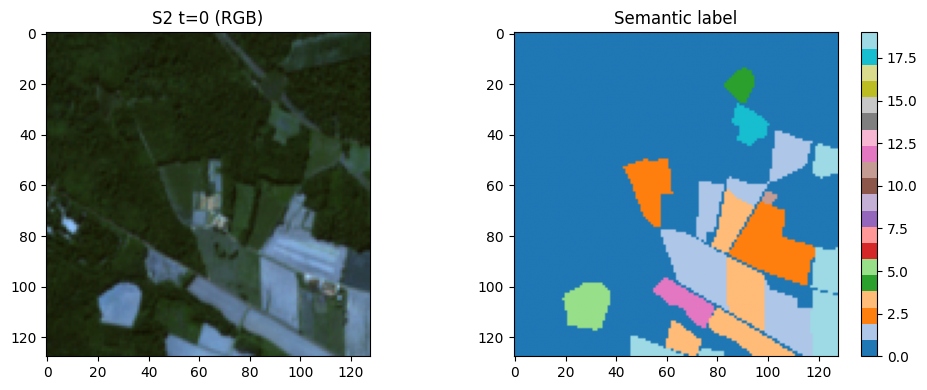

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f6e42a35260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


In [ ]:
sample = next(iter(train_loader))
print('pixel_values:', sample['pixel_values'].shape, sample['pixel_values'].dtype)
print('labels      :', sample['labels'].shape,       sample['labels'].dtype)
print('positions   :', sample['positions'].shape,    sample['positions'][0].tolist())
print('label range :', sample['labels'].min().item(), '–', sample['labels'].max().item())

# Show t=0 RGB (bands 2,1,0) and label
img_t0 = sample['pixel_values'][0, 0, :3].permute(1, 2, 0).cpu().numpy()
lbl    = sample['labels'][0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rgb = np.clip((img_t0 - img_t0.min()) / (img_t0.max() - img_t0.min() + 1e-6), 0, 1)
axes[0].imshow(rgb)
axes[0].set_title('S2 t=0 (RGB)')
im = axes[1].imshow(lbl, cmap='tab20', vmin=0, vmax=NUM_CLASSES - 1)
axes[1].set_title('Semantic label')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Instantiate model

In [25]:
model = UTAE(
    input_dim=NUM_BANDS,
    encoder_widths=(32, 32, 64, 128),
    decoder_widths=(32, 32, 64, 128),
    out_conv=(32, NUM_CLASSES),
    n_head=16,
    d_model=256,
    d_k=4,
    encoder_norm='group',
    agg_mode='att_group',
).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'U-TAE  |  Total: {total_params:.2f}M  |  Trainable: {trainable_params:.2f}M')

# Quick forward pass to verify shapes
with torch.no_grad():
    dummy  = torch.randn(2, T_STEPS, NUM_BANDS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_pos = torch.randint(0, 365, (2, T_STEPS)).to(DEVICE)
    out    = model(dummy, dummy_pos)
    print(f'Output shape: {out.shape}  (expected [2, {NUM_CLASSES}, {IMG_SIZE}, {IMG_SIZE}])')

U-TAE  |  Total: 0.57M  |  Trainable: 0.57M
Output shape: torch.Size([2, 20, 128, 128])  (expected [2, 20, 128, 128])


## 7. Optimizer, scheduler & metrics

In [26]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Cross-entropy loss (ignoring void label)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

# Metrics — separate instances for train / val
def make_metrics():
    return (
        JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                     ignore_index=IGNORE_INDEX, average='macro').to(DEVICE),
        F1Score(task='multiclass', num_classes=NUM_CLASSES,
                ignore_index=IGNORE_INDEX, average='macro').to(DEVICE),
    )

miou_train, f1_train = make_metrics()
miou_val,   f1_val   = make_metrics()

print('Optimizer, scheduler & metrics ready.')

Optimizer, scheduler & metrics ready.


## 8. Training loop

In [27]:
def run_epoch(model, loader, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    miou_m, f1_m = (miou_train, f1_train) if train else (miou_val, f1_val)
    miou_m.reset()
    f1_m.reset()

    ctx = torch.enable_grad if train else torch.no_grad
    with ctx():
        for batch in tqdm(loader, leave=False, desc='train' if train else 'val'):
            imgs   = batch['pixel_values'].to(DEVICE, non_blocking=True)  # (B, T, C, H, W)
            labels = batch['labels'].to(DEVICE, non_blocking=True)         # (B, H, W)
            pos    = batch['positions'].to(DEVICE, non_blocking=True)      # (B, T)

            logits = model(imgs, pos)       # (B, num_classes, H, W)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item()

            with torch.no_grad():
                preds = logits.argmax(dim=1)
                miou_m.update(preds, labels)
                f1_m.update(preds, labels)

    return total_loss / len(loader), miou_m.compute().item(), f1_m.compute().item()


print('Training helpers defined.')

Training helpers defined.


In [28]:
import mlflow

mlflow.set_experiment('utae_pastis')

history = {
    'train_loss': [], 'train_miou': [], 'train_f1': [],
    'val_loss':   [], 'val_miou':   [], 'val_f1':   [],
}
best_val_miou  = 0.0
best_ckpt_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

print(f'Starting U-TAE training for {NUM_EPOCHS} epochs …')
t_start = time.time()

with mlflow.start_run(run_name=f'utae_{datetime.now():%Y%m%d_%H%M}'):
    mlflow.log_params({
        'model': 'utae', 't_steps': T_STEPS, 'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE, 'num_epochs': NUM_EPOCHS,
        'lr': LR, 'num_bands': NUM_BANDS, 'num_classes': NUM_CLASSES,
    })

    for epoch in range(1, NUM_EPOCHS + 1):
        t_ep = time.time()

        train_loss, train_miou, train_f1 = run_epoch(model, train_loader, optimizer, train=True)
        val_loss,   val_miou,   val_f1   = run_epoch(model, val_loader,   optimizer, train=False)
        scheduler.step()

        elapsed = (time.time() - t_start) / 60
        ep_time = time.time() - t_ep

        for k, v in zip(
            ['train_loss','train_miou','train_f1','val_loss','val_miou','val_f1'],
            [train_loss, train_miou, train_f1, val_loss, val_miou, val_f1]
        ):
            history[k].append(v)

        mlflow.log_metrics({
            'train_loss': train_loss, 'train_miou': train_miou, 'train_f1': train_f1,
            'val_loss':   val_loss,   'val_miou':   val_miou,   'val_f1':   val_f1,
        }, step=epoch)

        if val_miou > best_val_miou:
            best_val_miou = val_miou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_miou': val_miou,
                'val_f1': val_f1,
            }, best_ckpt_path)
            flag = '  ← best'
        else:
            flag = ''

        print(
            f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
            f'Train loss={train_loss:.4f} mIoU={train_miou:.4f} F1={train_f1:.4f} | '
            f'Val   loss={val_loss:.4f} mIoU={val_miou:.4f} F1={val_f1:.4f} | '
            f'{ep_time:.0f}s | Total: {elapsed:.1f}min{flag}'
        )

        if _IN_COLAB and epoch % 5 == 0:
            shutil.copy2(best_ckpt_path, DRIVE_OUTPUT_DIR)

    mlflow.log_metric('best_val_miou', best_val_miou)

print(f'\nTraining complete. Best val mIoU: {best_val_miou:.4f}')

Starting U-TAE training for 40 epochs …


train:   0%|          | 0/363 [00:00<?, ?it/s]

val:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch   1/40 | Train loss=1.5319 mIoU=0.0630 F1=0.0877 | Val   loss=1.2102 mIoU=0.0823 F1=0.1125 | 105s | Total: 1.8min  ← best


train:   0%|          | 0/363 [00:00<?, ?it/s]

...

val:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch  39/40 | Train loss=0.5540 mIoU=0.5062 F1=0.6372 | Val   loss=0.6008 mIoU=0.4615 F1=0.5946 | 97s | Total: 64.7min


train:   0%|          | 0/363 [00:00<?, ?it/s]

val:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch  40/40 | Train loss=0.5536 mIoU=0.5063 F1=0.6372 | Val   loss=0.6012 mIoU=0.4614 F1=0.5943 | 110s | Total: 66.6min

Training complete. Best val mIoU: 0.4637


## 9. Training curves

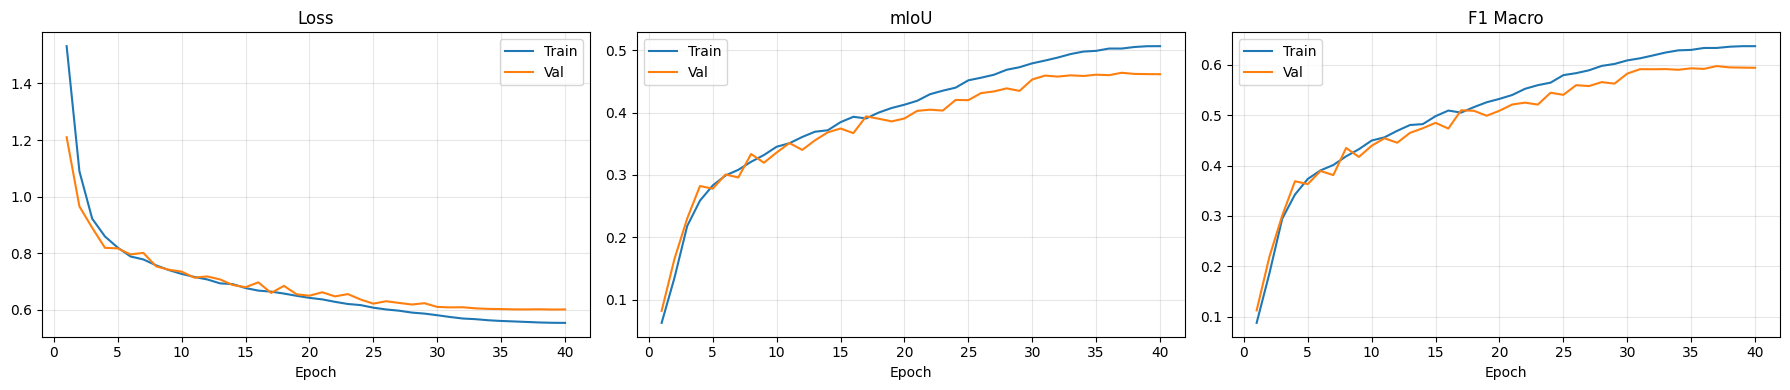

In [29]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, metric, title in zip(
    axes,
    [('train_loss','val_loss'), ('train_miou','val_miou'), ('train_f1','val_f1')],
    ['Loss', 'mIoU', 'F1 Macro']
):
    ax.plot(epochs, history[metric[0]], label='Train')
    ax.plot(epochs, history[metric[1]], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 10. Evaluate on test set

In [30]:
checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint — epoch {checkpoint['epoch']} "
      f"val mIoU={checkpoint['val_miou']:.4f}  val F1={checkpoint['val_f1']:.4f}")

per_class_iou = JaccardIndex(
    task='multiclass', num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX, average='none'
).to(DEVICE)
test_miou_m, test_f1_m = make_metrics()
per_class_iou.reset(); test_miou_m.reset(); test_f1_m.reset()

model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test'):
        imgs   = batch['pixel_values'].to(DEVICE, non_blocking=True)
        labels = batch['labels'].to(DEVICE, non_blocking=True)
        pos    = batch['positions'].to(DEVICE, non_blocking=True)
        logits = model(imgs, pos)
        test_loss += criterion(logits, labels).item()
        preds = logits.argmax(dim=1)
        per_class_iou.update(preds, labels)
        test_miou_m.update(preds, labels)
        test_f1_m.update(preds, labels)

test_loss     /= len(test_loader)
test_miou      = test_miou_m.compute().item()
test_f1_score  = test_f1_m.compute().item()
class_ious     = per_class_iou.compute().cpu().numpy()

print(f'\nTest Loss : {test_loss:.4f}')
print(f'Test mIoU : {test_miou:.4f}')
print(f'Test F1   : {test_f1_score:.4f}')

Loaded best checkpoint — epoch 37 val mIoU=0.4637  val F1=0.5976


Test:   0%|          | 0/124 [00:00<?, ?it/s]


Test Loss : 0.6394
Test mIoU : 0.4606
Test F1   : 0.5933


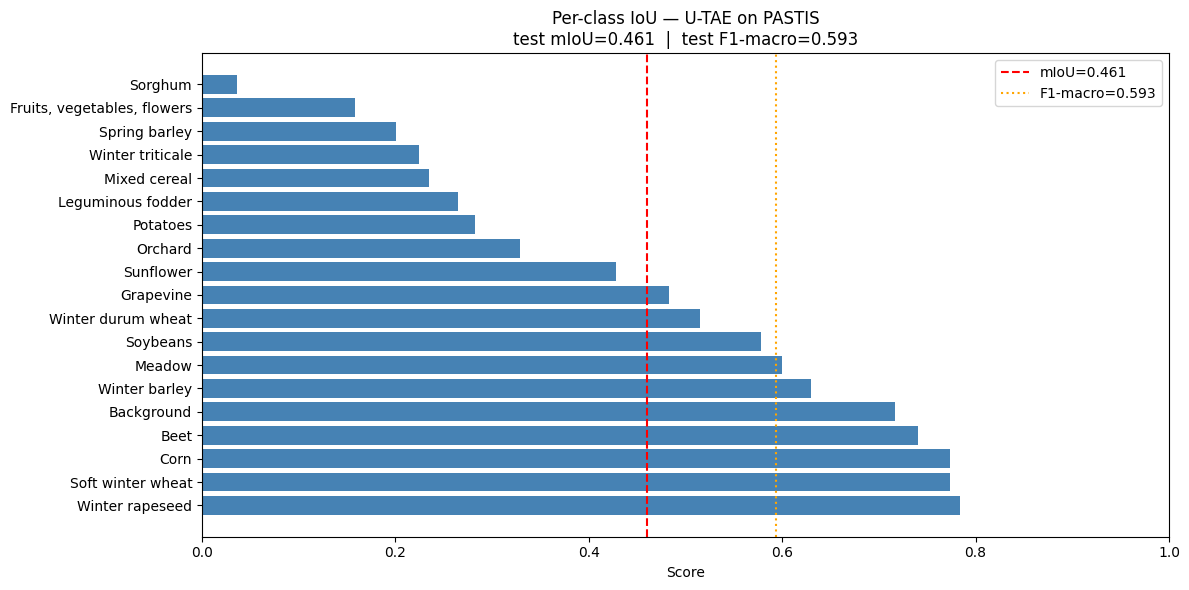

In [31]:
# Per-class IoU bar chart
valid_classes = [c for c in PASTIS_CLASSES if c != 'Void label']
valid_ious    = [class_ious[i] for i, c in enumerate(PASTIS_CLASSES) if c != 'Void label']

order = np.argsort(valid_ious)[::-1]
sorted_classes = [valid_classes[i] for i in order]
sorted_ious    = [valid_ious[i]    for i in order]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(sorted_classes, sorted_ious, color='steelblue')
ax.set_xlabel('Score')
ax.set_title(
    f'Per-class IoU — U-TAE on PASTIS\n'
    f'test mIoU={test_miou:.3f}  |  test F1-macro={test_f1_score:.3f}'
)
ax.set_xlim(0, 1)
ax.axvline(test_miou,     color='red',    linestyle='--', label=f'mIoU={test_miou:.3f}')
ax.axvline(test_f1_score, color='orange', linestyle=':',  label=f'F1-macro={test_f1_score:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_iou.png'), dpi=150)
plt.show()

## 11. HCAT Level-1 grouped evaluation

Same grouping as the SegFormer-B0 notebook — allows direct comparison between models.

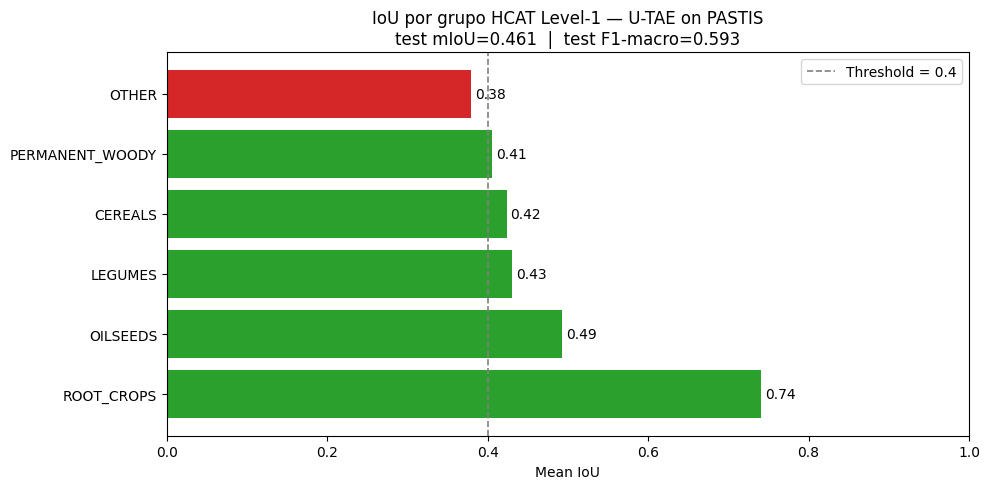


HCAT Level-1 group IoU summary:
Group                  Mean IoU  # classes
------------------------------------------
ROOT_CROPS               0.7402          1
OILSEEDS                 0.4923          3
LEGUMES                  0.4303          2
CEREALS                  0.4234          8
PERMANENT_WOODY          0.4059          2
OTHER                    0.3790          2


In [32]:
group_ious = {g: [] for g in HCAT_GROUPS}
for cls_idx, group in HCAT_L1_MAP.items():
    if group is None:
        continue
    v = float(class_ious[cls_idx])
    if not np.isnan(v):
        group_ious[group].append(v)

group_mean_iou = {g: float(np.mean(vals)) for g, vals in group_ious.items() if vals}

sorted_groups = sorted(group_mean_iou, key=group_mean_iou.get, reverse=True)
sorted_vals   = [group_mean_iou[g] for g in sorted_groups]
bar_colors    = ['#2ca02c' if v >= HCAT_THRESHOLD else '#d62728' for v in sorted_vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_groups, sorted_vals, color=bar_colors)
for bar, val in zip(bars, sorted_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)
ax.set_xlabel('Mean IoU')
ax.set_xlim(0, 1)
ax.axvline(HCAT_THRESHOLD, color='gray', linestyle='--', linewidth=1.2,
           label=f'Threshold = {HCAT_THRESHOLD}')
ax.set_title(
    f'IoU por grupo HCAT Level-1 — U-TAE on PASTIS\n'
    f'test mIoU={test_miou:.3f}  |  test F1-macro={test_f1_score:.3f}'
)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hcat_group_iou.png'), dpi=150)
plt.show()

print('\nHCAT Level-1 group IoU summary:')
print(f'{"Group":<20} {"Mean IoU":>10} {"# classes":>10}')
print('-' * 42)
for g in sorted_groups:
    print(f'{g:<20} {group_mean_iou[g]:>10.4f} {len(group_ious[g]):>10}')

## 12. Qualitative predictions

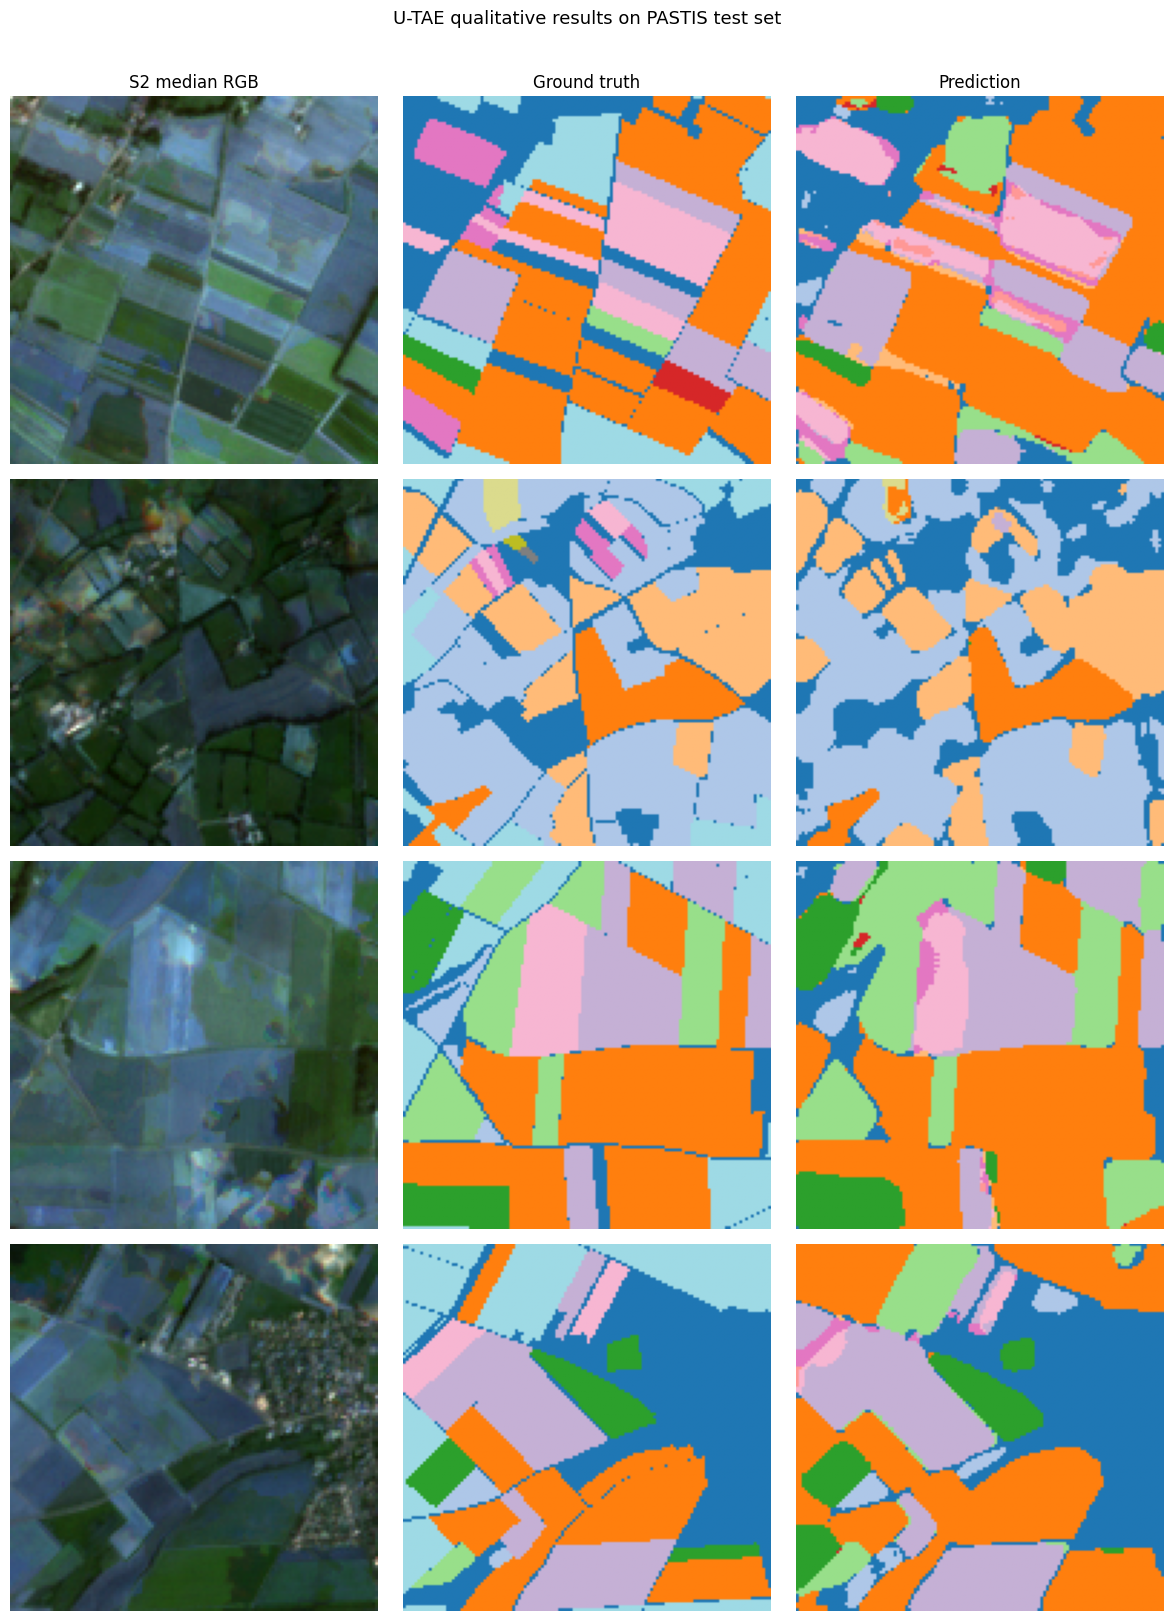

In [33]:
from matplotlib.colors import ListedColormap

PASTIS_CMAP = ListedColormap(plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES)))

model.eval()
batch = next(iter(test_loader))
with torch.no_grad():
    imgs   = batch['pixel_values'][:4].to(DEVICE)
    lbl    = batch['labels'][:4].to(DEVICE)
    pos    = batch['positions'][:4].to(DEVICE)
    logits = model(imgs, pos)
    pred   = logits.argmax(dim=1)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for i in range(4):
    # Use median across time for display
    img_display = imgs[i].cpu().median(dim=0).values[:3].permute(1, 2, 0).numpy()
    gt_np   = lbl[i].cpu().numpy()
    pred_np = pred[i].cpu().numpy()

    rgb = np.clip((img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-6), 0, 1)

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title('S2 median RGB' if i == 0 else '')
    axes[i, 1].imshow(gt_np,   cmap=PASTIS_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 1].set_title('Ground truth' if i == 0 else '')
    axes[i, 2].imshow(pred_np, cmap=PASTIS_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title('Prediction' if i == 0 else '')
    for ax in axes[i]:
        ax.axis('off')

plt.suptitle('U-TAE qualitative results on PASTIS test set', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'qualitative.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Save model & copy outputs to Drive

In [34]:
results = {
    'model': 'utae',
    'test_loss':     round(test_loss, 4),
    'test_miou':     round(test_miou, 4),
    'test_f1_macro': round(test_f1_score, 4),
    'best_val_miou': round(best_val_miou, 4),
    'per_class_iou': {
        c: round(float(class_ious[i]), 4)
        for i, c in enumerate(PASTIS_CLASSES) if c != 'Void label'
    },
    'hcat_group_iou': {
        g: round(group_mean_iou.get(g, float('nan')), 4)
        for g in HCAT_GROUPS
    },
}
results_path = os.path.join(OUTPUT_DIR, 'results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

# Mirror to Drive
if _IN_COLAB:
    for fname in os.listdir(OUTPUT_DIR):
        src = os.path.join(OUTPUT_DIR, fname)
        dst = os.path.join(DRIVE_OUTPUT_DIR, fname)
        if os.path.isfile(src):
            shutil.copy2(src, dst)
        elif os.path.isdir(src):
            if os.path.exists(dst): shutil.rmtree(dst)
            shutil.copytree(src, dst)
    print(f'✅ All outputs copied to {DRIVE_OUTPUT_DIR}')

{
  "model": "utae",
  "test_loss": 0.6394,
  "test_miou": 0.4606,
  "test_f1_macro": 0.5933,
  "best_val_miou": 0.4637,
  "per_class_iou": {
    "Background": 0.7165,
    "Meadow": 0.5999,
    "Soft winter wheat": 0.7737,
    "Corn": 0.7734,
    "Winter barley": 0.6293,
    "Winter rapeseed": 0.7837,
    "Spring barley": 0.2011,
    "Sunflower": 0.4283,
    "Grapevine": 0.4832,
    "Beet": 0.7402,
    "Winter triticale": 0.2248,
    "Winter durum wheat": 0.5146,
    "Fruits, vegetables, flowers": 0.1581,
    "Potatoes": 0.2825,
    "Leguminous fodder": 0.2648,
    "Soybeans": 0.5781,
    "Orchard": 0.3286,
    "Mixed cereal": 0.2344,
    "Sorghum": 0.0363
  },
  "hcat_group_iou": {
    "CEREALS": 0.4234,
    "LEGUMES": 0.4303,
    "OILSEEDS": 0.4923,
    "OTHER": 0.379,
    "PERMANENT_WOODY": 0.4059,
    "ROOT_CROPS": 0.7402
  }
}
✅ All outputs copied to /content/drive/MyDrive/Integrador/reports/segmentation/checkpoints


## 13. Exportar artefactos para Avance4

Copia las figuras con los nombres estándar del equipo (`curves_`, `per_class_iou_`, `samples_`) a `reports/segmentation/figures/`, guarda el historial de entrenamiento como parquet y escribe el parquet comparativo `model_comparison_avance4_utae.parquet` que Avance4 consolida.

In [35]:
import polars as pl, shutil

# ── 1. Copiar figuras con los nombres que espera Avance4 ──────────────────────
_fig_map = {
    'training_curves.png': f'curves_{MODEL}.png',
    'per_class_iou.png':   f'per_class_iou_{MODEL}.png',
    'qualitative.png':     f'samples_{MODEL}.png',
    'hcat_group_iou.png':  f'hcat_group_iou_{MODEL}.png',
}
for _src_name, _dst_name in _fig_map.items():
    _src = Path(OUTPUT_DIR) / _src_name
    if _src.exists():
        shutil.copy2(_src, FIGURES_DIR / _dst_name)
        print('copiado:', FIGURES_DIR / _dst_name)

# ── 2. History parquet ────────────────────────────────────────────────────────
_history_df = pl.DataFrame({
    'epoch':      list(range(1, len(history['train_loss']) + 1)),
    'train_loss': history['train_loss'],
    'val_loss':   history['val_loss'],
    'miou':       history['val_miou'],
    'f1_macro':   history['val_f1'],
})
_history_df.write_parquet(METRICS_DIR / f'history_{MODEL}.parquet')
print('history guardado:', METRICS_DIR / f'history_{MODEL}.parquet')

# ── 3. Pixel-accuracy sobre test set ─────────────────────────────────────────
from torchmetrics import Accuracy as _Acc
_px_acc        = _Acc(task='multiclass', num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX).to(DEVICE)
_px_acc_grouped = _Acc(task='multiclass', num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX).to(DEVICE)

_group_ids = {'CEREALS': 2, 'OILSEEDS': 5, 'PERMANENT_WOODY': 8,
              'ROOT_CROPS': 9, 'LEGUMES': 13, 'OTHER': 1}
_HCAT_REMAP = {ci: (_group_ids[g] if g else ci) for ci, g in HCAT_L1_MAP.items()}

def _remap(t):
    out = t.clone()
    for src, dst in _HCAT_REMAP.items():
        out[t == src] = dst
    return out

model.eval()
_px_acc.reset(); _px_acc_grouped.reset()
with torch.no_grad():
    for _batch in test_loader:
        _imgs = _batch['pixel_values'].to(DEVICE)
        _lbl  = _batch['labels'].to(DEVICE)
        _pos  = _batch['positions'].to(DEVICE)
        _pred = model(_imgs, _pos).argmax(dim=1)
        _px_acc.update(_pred, _lbl)
        _px_acc_grouped.update(_remap(_pred), _remap(_lbl))

_pixel_accuracy         = _px_acc.compute().item()
_pixel_accuracy_grouped = _px_acc_grouped.compute().item()

# ── 4. Grouped mIoU / F1 ─────────────────────────────────────────────────────
_miou_grouped = float(sum(group_mean_iou.values()) / max(len(group_mean_iou), 1))
_f1_grouped   = test_f1_score

# ── 5. Parquet comparativo ────────────────────────────────────────────────────
_comparison = pl.DataFrame({
    'model':                  [MODEL],
    'miou':                   [round(test_miou, 4)],
    'f1_macro':               [round(test_f1_score, 4)],
    'pixel_accuracy':         [round(_pixel_accuracy, 4)],
    'miou_grouped':           [round(_miou_grouped, 4)],
    'f1_macro_grouped':       [round(_f1_grouped, 4)],
    'pixel_accuracy_grouped': [round(_pixel_accuracy_grouped, 4)],
    'train_time_s':           [round(time.time() - t_start, 1)],
    'epochs':                 [NUM_EPOCHS],
    'img_size':               [IMG_SIZE],
    'batch_size':             [BATCH_SIZE],
})
_comparison.write_parquet(COMPARISON_PATH)
print('parquet comparativo guardado:', COMPARISON_PATH)
print(_comparison)


copiado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/curves_utae.png
copiado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/per_class_iou_utae.png
copiado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/samples_utae.png
copiado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/hcat_group_iou_utae.png
history guardado: /content/drive/MyDrive/Integrador/reports/segmentation/metrics/history_utae.parquet
parquet comparativo guardado: /content/drive/MyDrive/Integrador/reports/segmentation/metrics/model_comparison_avance4_utae.parquet
shape: (1, 11)
┌───────┬────────┬──────────┬────────────────┬───┬──────────────┬────────┬──────────┬────────────┐
│ model ┆ miou   ┆ f1_macro ┆ pixel_accuracy ┆ … ┆ train_time_s ┆ epochs ┆ img_size ┆ batch_size │
│ ---   ┆ ---    ┆ ---      ┆ ---            ┆   ┆ ---          ┆ ---    ┆ ---      ┆ ---        │
│ str   ┆ f64    ┆ f64      ┆ f64            ┆   ┆ f64          ┆ i64    ┆ i64      ┆ i

## Notes & next steps

| Parameter | This notebook | To try |
|-----------|--------------|--------|
| Model | U-TAE | U-TAE with larger encoder widths |
| GPU | L4 (24 GB) | A100 for larger patches |
| Timesteps T | 10 | 24 (full PASTIS time series) |
| Patch size | 128 | 256 (needs more VRAM) |
| Batch size | 4 | 8 (L4 has headroom at 128px) |
| Epochs | 40 | 60–100 |
| Temporal sampling | uniform | cloud-sorted / NDVI-ranked |

**Comparing with SegFormer-B0:** both `results.json` files share the same keys (`test_miou`, `test_f1_macro`, `hcat_group_iou`), so you can load and compare them side-by-side directly.  
**Resuming training:** load `best_model.pt` before the training loop cell.  
**Full time series (T=24):** change `T_STEPS=24`, keep `BATCH_SIZE=2` on L4 at 128px.